In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

In [24]:
df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["survived"].value_counts())

features = df.drop(columns="survived")
target = df["survived"]

train_features, test_features, train_target, test_target = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("\nTraining set:", train_features.shape)
print("Testing set :", test_features.shape)

print("\nTraining class distribution:")
print(train_target.value_counts())

Dataset shape: (891, 15)

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Training set: (712, 14)
Testing set : (179, 14)

Training class distribution:
survived
0    439
1    273
Name: count, dtype: int64


In [25]:
numeric_features = ["age", "fare", "sibsp", "parch"]

categorical_features = ["sex", "embarked"]


numeric_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42
    )
}

trained_models = {}

for name, estimator in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(train_features, train_target)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [27]:
results = []

predictions = {}
probabilities = {}

for name, model in trained_models.items():

    prediction = model.predict(test_features)
    probability = model.predict_proba(test_features)[:, 1]

    predictions[name] = prediction
    probabilities[name] = probability

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(test_target, prediction),
        "Precision": precision_score(test_target, prediction),
        "Recall": recall_score(test_target, prediction),
        "F1 Score": f1_score(test_target, prediction),
        "ROC AUC": roc_auc_score(test_target, probability)
    })

classification_results = pd.DataFrame(results)

classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7989,0.7797,0.6667,0.7188,0.8194
1,Decision Tree,0.8101,0.7966,0.6812,0.7344,0.8309
2,Random Forest,0.7933,0.7667,0.6667,0.7132,0.8238


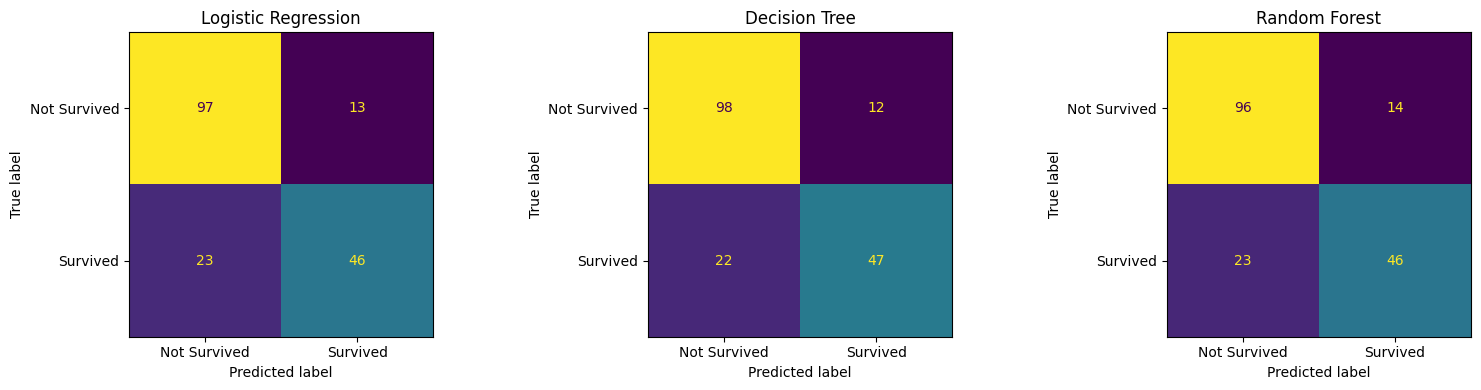

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, prediction) in zip(axes, predictions.items()):

    cm = confusion_matrix(test_target, prediction)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    )

    display.plot(ax=ax, colorbar=False)

    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

In [30]:
# ============================================
# Imbalance Handling Comparison
# ============================================

# Preprocess the training data
X_train_processed = preprocessor.fit_transform(train_features)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(test_features)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing :", X_test_processed.shape)

print("\nOriginal training class distribution:")
print(train_target.value_counts())


# --------------------------------------------
# 1. Baseline Random Forest
# --------------------------------------------

rf_baseline = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

rf_baseline.fit(X_train_processed, train_target)

pred_baseline = rf_baseline.predict(X_test_processed)


# --------------------------------------------
# 2. Class Weight = Balanced
# --------------------------------------------

rf_balanced = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train_processed, train_target)

pred_balanced = rf_balanced.predict(X_test_processed)


# --------------------------------------------
# 3. SMOTE
# --------------------------------------------

smote = SMOTE(random_state=42)

X_train_smote, target_train_smote = smote.fit_resample(
    X_train_processed,
    train_target
)

print("\nClass distribution after SMOTE:")
print(pd.Series(target_train_smote).value_counts())


rf_smote = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    target_train_smote
)

pred_smote = rf_smote.predict(X_test_processed)


# --------------------------------------------
# Compare the three approaches
# --------------------------------------------

imbalance_results = []

for name, prediction in [
    ("Baseline", pred_baseline),
    ("Class Weight = Balanced", pred_balanced),
    ("SMOTE", pred_smote)
]:

    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(test_target, prediction),
        "Recall": recall_score(test_target, prediction),
        "F1 Score": f1_score(test_target, prediction)
    })


imbalance_results = pd.DataFrame(imbalance_results)

print("\n=== Imbalance Handling Comparison ===")
print(imbalance_results.round(4).to_string(index=False))

Training data after preprocessing: (712, 9)
Testing data after preprocessing : (179, 9)

Original training class distribution:
survived
0    439
1    273
Name: count, dtype: int64

Class distribution after SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

=== Imbalance Handling Comparison ===
               Strategy  Precision  Recall  F1 Score
               Baseline     0.7667  0.6667    0.7132
Class Weight = Balanced     0.7586  0.6377    0.6929
                  SMOTE     0.6857  0.6957    0.6906


In [31]:
rf_tuned = RandomForestClassifier(
    oob_score=True,
    random_state=42
)

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_processed, train_target)

print("=== Random Forest Hyperparameter Tuning ===")
print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest CV accuracy: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

print(f"OOB score: {best_rf.oob_score_:.4f}")

=== Random Forest Hyperparameter Tuning ===
Best parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}

Best CV accuracy: 0.8161
OOB score: 0.8146


In [33]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train using preprocessed training data
dt.fit(X_train_processed, y_train)

# Predictions
y_pred_dt = dt.predict(X_test_processed)
y_prob_dt = dt.predict_proba(X_test_processed)[:, 1]

print("Decision Tree trained successfully.")
print(f"Test accuracy: {(y_pred_dt == y_test).mean():.4f}")

Decision Tree trained successfully.
Test accuracy: 0.8101


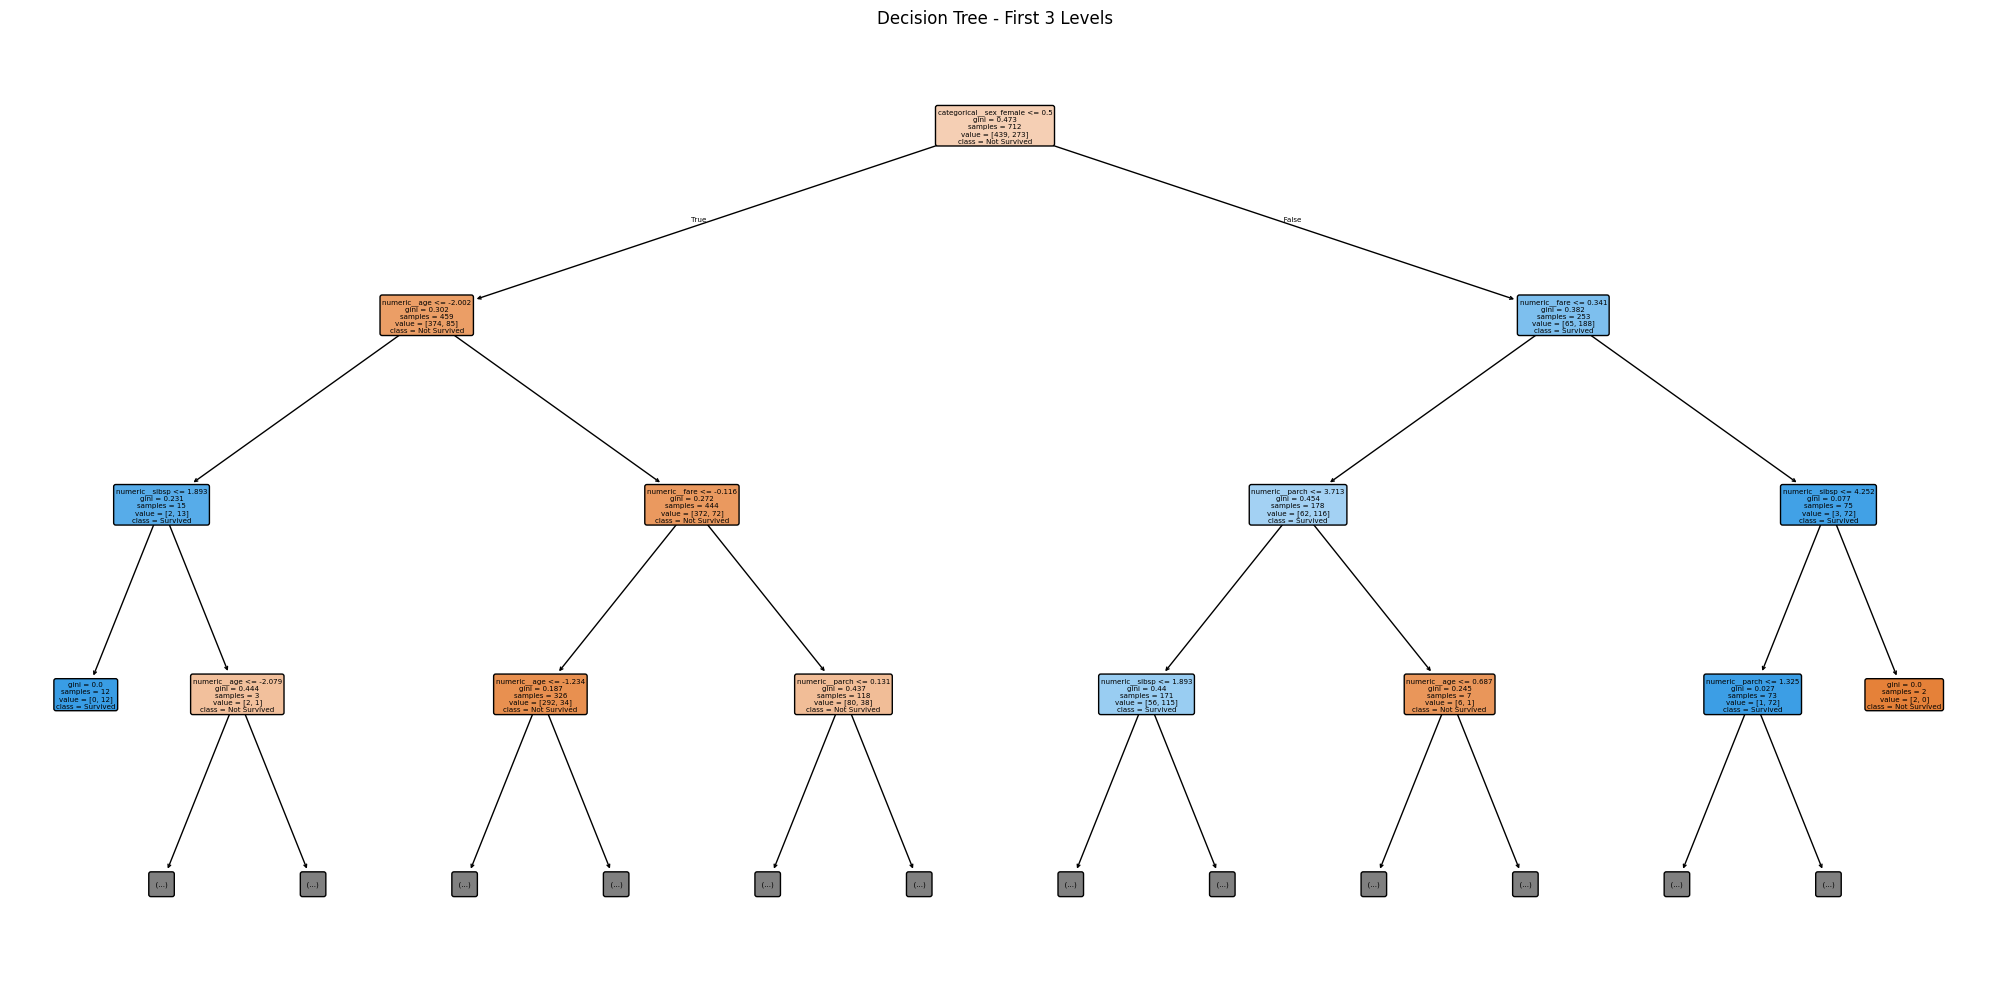

In [34]:
from sklearn.tree import plot_tree

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree - First 3 Levels")
plt.tight_layout()

plt.savefig("decision_tree.png", dpi=150)
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Logistic Regression
# -----------------------------
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)
y_prob_lr = lr.predict_proba(X_test_processed)[:, 1]


# -----------------------------
# Decision Tree
# -----------------------------
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)
y_prob_dt = dt.predict_proba(X_test_processed)[:, 1]


# -----------------------------
# Random Forest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]


print("All three models trained successfully.")

All three models trained successfully.


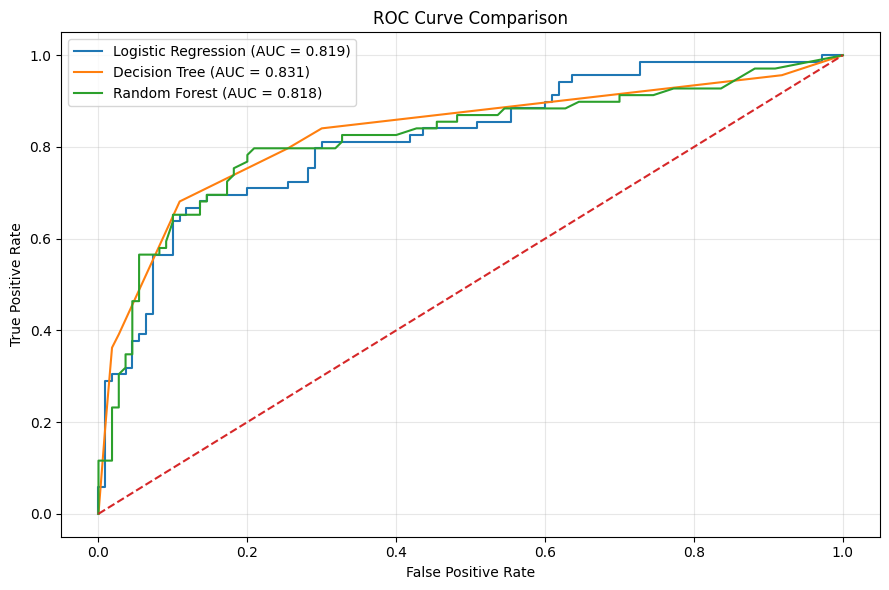

=== ROC-AUC Scores ===
Logistic Regression: 0.8194
Decision Tree:       0.8309
Random Forest:       0.8184


In [39]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr, tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_dt, tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

print("=== ROC-AUC Scores ===")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Decision Tree:       {auc_dt:.4f}")
print(f"Random Forest:       {auc_rf:.4f}")

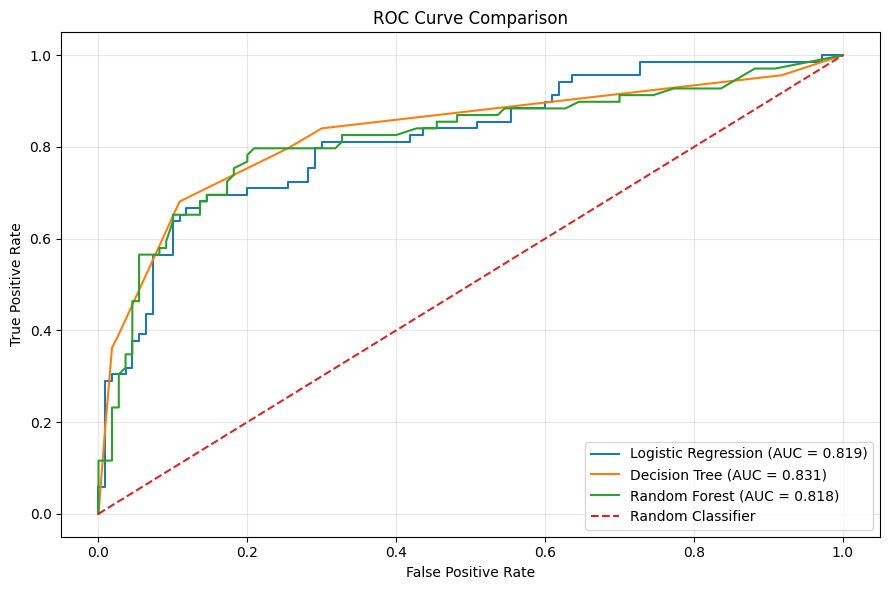

In [42]:
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

In [43]:
# Regression target
regression_target = "fare"

# Remove fare from the features
X_reg = df.drop(columns=[regression_target])

y_reg = df[regression_target]

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train_reg.shape)
print("Testing shape :", X_test_reg.shape)

Training shape: (712, 14)
Testing shape : (179, 14)


In [44]:
numeric_reg_features = [
    "age",
    "sibsp",
    "parch"
]

categorical_reg_features = [
    "sex",
    "embarked"
]

numeric_reg_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_reg_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", numeric_reg_transformer, numeric_reg_features),
    ("cat", categorical_reg_transformer, categorical_reg_features)
])

In [45]:
from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_train_reg, y_train_reg)

y_pred_reg = regression_pipeline.predict(X_test_reg)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_reg)
)

r2 = r2_score(y_test_reg, y_pred_reg)

n = len(y_test_reg)
p = X_test_reg.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("=== Linear Regression Results ===")
print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"R²:          {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

=== Linear Regression Results ===
MAE:         21.4833
RMSE:        34.5198
R²:          0.2299
Adjusted R²: 0.1642


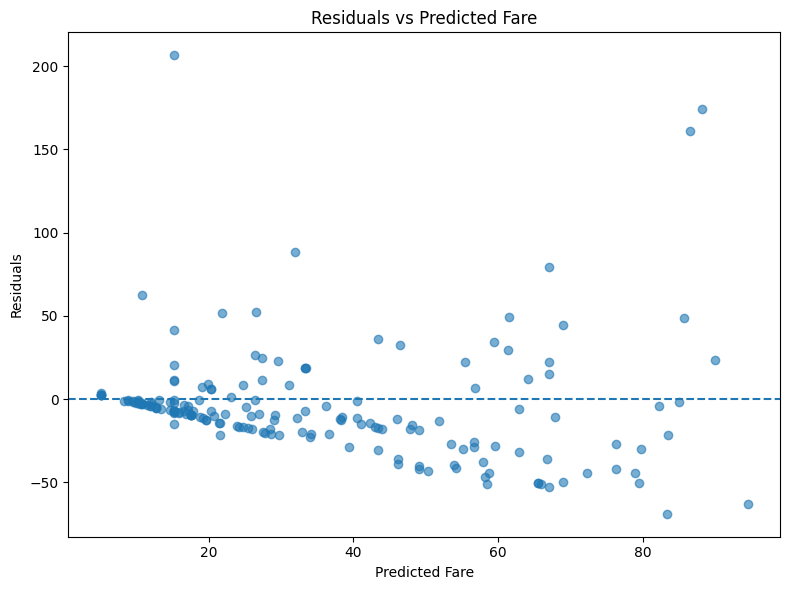

In [ ]:
# Residual analysis

residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Fare")

plt.tight_layout()
plt.savefig("fare_residuals.png", dpi=150)
plt.show()

In [48]:
print("=== Residual Statistics ===")
print(f"Mean residual:   {residuals.mean():.4f}")
print(f"Std residual:    {residuals.std():.4f}")
print(f"Min residual:    {residuals.min():.4f}")
print(f"Max residual:    {residuals.max():.4f}")

=== Residual Statistics ===
Mean residual:   -4.2958
Std residual:    34.3475
Min residual:    -68.8944
Max residual:    206.5498


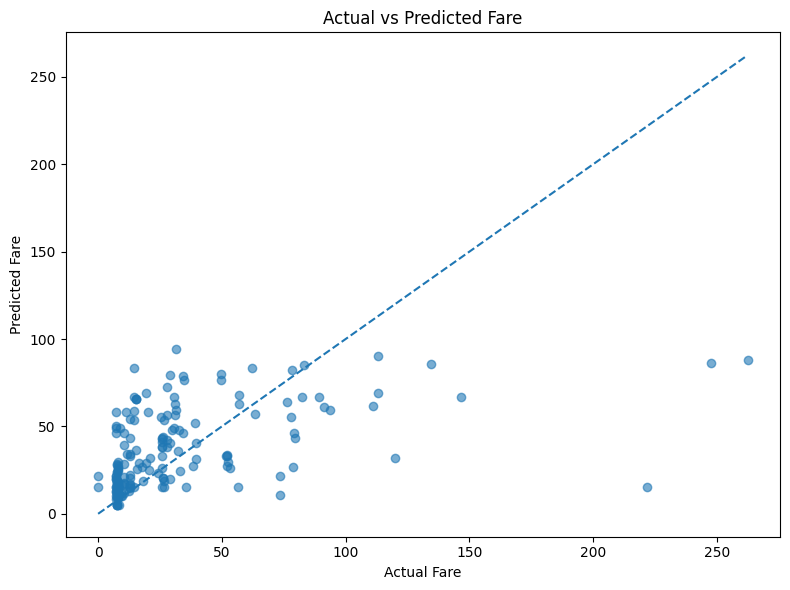

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

plt.tight_layout()
plt.savefig("fare_actual_vs_predicted.png", dpi=150)
plt.show()

In [52]:
# Final classification model comparison

classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        auc_lr,
        auc_dt,
        auc_rf
    ]
})

classification_results = classification_results.round(4)

print("=== Final Classification Model Comparison ===")
print(classification_results.to_string(index=False))

=== Final Classification Model Comparison ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7989     0.7797  0.6667    0.7188   0.8194
      Decision Tree    0.8101     0.7966  0.6812    0.7344   0.8309
      Random Forest    0.7821     0.7500  0.6522    0.6977   0.8184


## Final Classification Conclusion

Among the three classification models evaluated, the Decision Tree achieved the best overall performance.

The Decision Tree obtained an accuracy of 81.01%, precision of 79.66%, recall of 68.12%, F1 score of 73.44%, and ROC-AUC of 0.8309.

Logistic Regression achieved an accuracy of 79.89% and ROC-AUC of 0.8194, while Random Forest achieved an accuracy of 78.21% and ROC-AUC of 0.8184.

Based on the evaluation metrics, the Decision Tree was selected as the best-performing classification model for this dataset.

In [53]:
best_model = classification_results.loc[
    classification_results["ROC-AUC"].idxmax()
]

print("=== Best Classification Model ===")
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.4f}")

=== Best Classification Model ===
Model: Decision Tree
Accuracy: 0.8101
Precision: 0.7966
Recall: 0.6812
F1 Score: 0.7344
ROC-AUC: 0.8309
